# Emulation

Now that we have the quantile maps for our indicator `heating-degree-days`, we can, in conjunction with GMT ensemble simulations obtained from a simple climate model (how to obtain them with FaIR is described in `005_run_FaIR.ipynb`), finally produce emulations, consisting of requested quantiles of the indicator's distribution in each requested year, following the scenario. Those emulations can have:

1. **Constant weighting**, e.g. only latitude weighting, unchanging over time
2. **Time-varying weighting**, something you might use when socioeconomic conditions change (e.g. population weighting, updated for each population scenario/year)

With an additional preprocessing step, creating a lookup table, one can also obtain uncertainty-aware, temporally and spatially correlated regional timeseries (this will be described in a forthcoming publication and tutorial)

First we need to (re-)define our indicator and paths, as done in `001_preprocessing_data_setup.ipynb` and `002_preprocessing_regional_averages.ipynb`. Usually you'd set these directly in `config.toml`; we set them here in code instead, purely so the tutorial is self-contained and doesn't require editing the config file.

In [15]:
import xarray as xr
import pandas as pd
import numpy as np
from rimeX.config import CONFIG 

CONFIG['isimip.download_folder'] = 'data/downloads'
CONFIG['indicators.folder'] = 'data/indicators'
CONFIG['isimip.climate_impact_explorer'] = 'data'
CONFIG['indicator.heating-degree-days'] = {
    'frequency': 'annual',
    'units': 'days*°C',
    'isimip_meta': {
        'db_file': 'data/heating-degree-days.json'
    }
}
CONFIG['preprocessing.regional.weights'] = ["latWeight"]
CONFIG['preprocessing.regional.masks_folder'] = 'data/continental_masks'

Now we define the config specific to an emulation with constant weighting:

* the path to the quantile maps we created during preprocessing (`001_preprocessing_data_setup.ipynb` to `003_preprocessing_quantilemaps.ipynb`), here we use the quantilemap specific to the africa region
* the path to the GMT ensemble simulation file for the scenario retrieved from an SCM (Simple Climate Model), which gives the prior distribution of global mean temperature (GMT) for the scenario, for each year we want to emulate. You can see how to generate this yourself with FaIR in `005_run_FaIR.ipynb`. For this tutorial, we've included a ready-made GMT file for the NGFS Current Policies scenario, simulated with MAGICC.

The GMT file is a CSV shaped like this:

```
time,0,1,2,...,599
1750,-0.141,-0.028,-0.138,...,-0.150
1751,-0.116,0.003,-0.107,...,-0.128
...
```

- The first column, `time`, is the year.
- Every other column is one **ensemble member** of the SCM run (here, 600 members, labeled `0` to `599`) -- i.e. one possible realization of GMT for that scenario, reflecting the model's internal uncertainty (e.g. carbon cycle feedbacks, climate sensitivity).
- Each cell is that member's GMT value (in °C) for that year, expressed relative to the same baseline the quantile maps were built with (e.g. pre-industrial).

Rather than a single best-guess GMT trajectory per year, you get a whole **distribution** of plausible GMT values per year -- and that's exactly what the emulator needs: for each year, it looks up where each ensemble member's GMT value falls within the quantile map's warming-level axis, and samples the corresponding indicator quantile. This is how uncertainty in the climate response (via the GMT ensemble) gets propagated through to uncertainty in the emulated indicator, on top of the uncertainty already captured across models in the quantile map itself.

In [16]:
GMT_ensemble_file = 'data/scenario_data/NGFS_current_policy.csv'
quantile_map = 'data/quantilemaps_regional_admin/heating-degree-days/AFR/heating-degree-days_annual_afr_latweight_eq.nc'


## Running the emulation

`make_quantilemap_prediction` takes a quantile map (for a single region) and a GMT ensemble, and produces the emulated indicator distribution for each year in the GMT ensemble.

```python
make_quantilemap_prediction(
    a,                                 # xa.DataArray as produced by make_quantile_map_array,
                                       # with dims ("warming_level", "quantile", ...)
    gmt,                               # pandas DataFrame: years as index, ensemble members as columns
    samples=100,                       # number of samples to draw per year
    seed=42,                           # random seed
    quantiles=[0.5, .05, .95],         # output quantiles to compute (None returns all samples, unreduced)
    mode="deterministic",              # "deterministic", "montecarlo", or "factorial" -- see below
    clip=False,                        # if True, clip GMT values to the quantile map's warming-level range
                                        # instead of returning NaN outside that range
    skipna=False,                      # skip NaN values when computing the output quantiles
)
```

**How it works:** for each of the `samples` draws, one GMT value and one impact-distribution quantile are jointly sampled and interpolated against the quantile map's `(warming_level, quantile)` grid -- this is what turns "here's a warming level" into "here's the resulting indicator value." The three `mode` options differ in exactly how GMT and quantile are paired up:
- `"deterministic"` (default): GMT is resampled deterministically across its own quantiles, giving a reproducible, evenly-spaced representation of its distribution.
- `"montecarlo"`: GMT ensemble members are drawn at random (with replacement).
- `"factorial"`: every GMT value is combined with every quantile-map quantile, giving `samples * gmt.shape[1]` total combinations.

**Output:** an `xr.DataArray` with dimensions `(year, sample)` if `quantiles=None`, or `(year, quantile)` once reduced to the requested output quantiles (as in our example, where we request `[0.5, .05, .95]`, the emulated median plus a 90% interval). 

Note we reindex the GMT ensemble to 5-year steps first (`GMT_ensemble.reindex(...)`) purely to keep the number of years emulated small and fast for this tutorial, you can emulate every year if you like.

In [17]:
from rimeX.preproc.quantilemaps import load_GMT_ensemble, make_quantilemap_prediction
GMT_ensemble = load_GMT_ensemble(GMT_ensemble_file, projection_baseline=None,projection_baseline_offset=None).reindex(np.arange(2015,2100+1,5))
quantilemap = xr.load_dataset(quantile_map)
emulation = make_quantilemap_prediction(quantilemap.sel(region = 'AFR')['heating-degree-days'], GMT_ensemble, samples=5000, quantiles=[0.5, .05, .95], skipna = True) #skipna is necessary 
print(emulation)

[14:04:51 | rimeX | INFO] Load GMT ensemble data/scenario_data/NGFS_current_policy.csv with baseline None and offset None


<xarray.DataArray (quantile: 3, year: 18)> Size: 432B
array([[143.79904883, 137.39485844, 132.16239151, 127.2711932 ,
        122.55257945, 118.75513783, 114.84468826, 110.56146724,
        106.3328931 , 101.4557219 ,  97.26205979,  92.34583042,
         89.69606011,  86.75157308,  84.40651332,  82.24848081,
         80.07984698,  78.93582498],
       [118.31095037, 110.75434248, 107.19666416, 104.06750963,
         97.29539246,  91.233575  ,  85.13689073,  77.9945674 ,
         74.23829035,  71.1100847 ,  67.0687291 ,  62.19052399,
         59.14634995,  57.39295064,  55.01169459,  53.28875384,
         49.42215385,  48.8090933 ],
       [175.12461363, 167.29655969, 161.98136206, 158.32896286,
        151.47834776, 146.84459203, 141.77230496, 136.56974224,
        134.6081774 , 131.81067433, 129.97028041, 127.29747376,
        126.00096739, 123.7112792 , 122.23589468, 120.70912793,
        118.37133599, 116.58609413]])
Coordinates:
  * quantile  (quantile) float64 24B 0.5 0.05 0.95
  

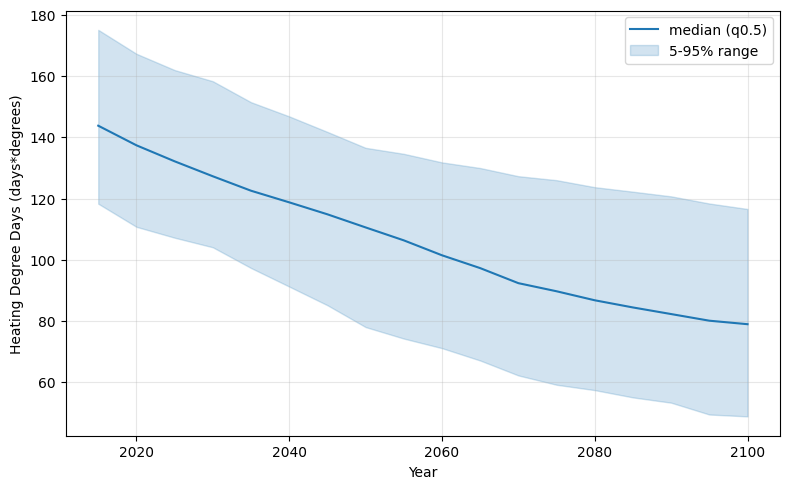

In [18]:
import matplotlib.pyplot as plt

def plot_emulation_timeseries(da, title=None, median_q=0.5, lower_q=0.05, upper_q=0.95):
    fig, ax = plt.subplots(figsize=(8, 5))

    median = da.sel(quantile=median_q)
    lower = da.sel(quantile=lower_q)
    upper = da.sel(quantile=upper_q)

    ax.plot(da.year, median, color="C0", label=f"median (q{median_q})")
    ax.fill_between(da.year, lower, upper, color="C0", alpha=0.2,
                     label=f"{int(lower_q*100)}-{int(upper_q*100)}% range")

    ax.set_xlabel("Year")
    ax.set_ylabel(f"Heating Degree Days (days*degrees)")
    ax.set_title(title or da.name)
    ax.legend()
    ax.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()

plot_emulation_timeseries(emulation)

If you want to make **gridded emulations** (emulating the distributional response per gridcell instead of aggregated to a region), you can use the same `make_quantilemap_prediction` function -- you just pass in a quantile map that has `lat`/`lon` dimensions instead of a `region` dimension, as produced with `map=True` in `003_preprocessing_quantilemaps.ipynb`. This looks like:

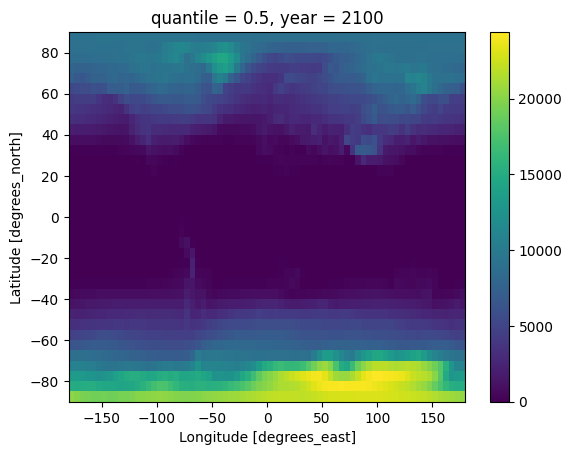

In [19]:
quantile_map = 'data/quantilemaps/heating-degree-days/heating-degree-days_annual_quantilemaps_eq.nc'
quantilemap = xr.load_dataset(quantile_map)
emulation = make_quantilemap_prediction(quantilemap['heating-degree-days'], GMT_ensemble, samples=100, quantiles=[0.5, .05, .95], skipna = True) #skipna is necessary 
emulation.sel(quantile = 0.5, year = 2100).plot()

## Time-sensitive weighting for emulations of regionally aggregated indicators

If you want to change the weighting scheme partway through the emulation, e.g. to account for changing socioeconomic conditions, such as population weights that update every decade, use `make_timesensitive_quantilemap_prediction` instead of a single call to `make_quantilemap_prediction`.

```python
make_timesensitive_quantilemap_prediction(
    quantile_maps,                     # dict: {year: path_to_quantilemap_nc_file}
    gmt,                                # pandas DataFrame: years as index, ensemble members as columns
    region,                             # region to make the prediction for, e.g. "AFR"
    indicator,                          # indicator name, e.g. "heating-degree-days"
    samples=100, seed=42,
    quantiles=[0.5, .05, .95],
    mode="deterministic", clip=False, skipna=False,
)
```

**How it works:** rather than one static quantile map for the whole timeseries, you supply a `{year: path}` dictionary with one quantile map file per year (or per period) you want to emulate. For each year, it opens that year's quantile map, selects the requested `region`, and calls `make_quantilemap_prediction` using only that year's GMT value(s), then concatenates the results across years along a `year` dimension.

In our example below, all years point to the *same* quantile map file (constant weighting again because we only preprocessed one weighting option due to data storage space considerations for this tutorial), but in a real time-sensitive setup, each year's path would point to a quantile map built with that year's specific weighting (e.g. `heating-degree-days_annual_afr_pop2030.nc`, `..._pop2040.nc`, etc.), so the weighting genuinely evolves as you move through the timeseries.

**Output:** same shape as `make_quantilemap_prediction`, an `xa.DataArray` with dimensions `(year, quantile)` (or `(year, sample)` if `quantiles=None`).

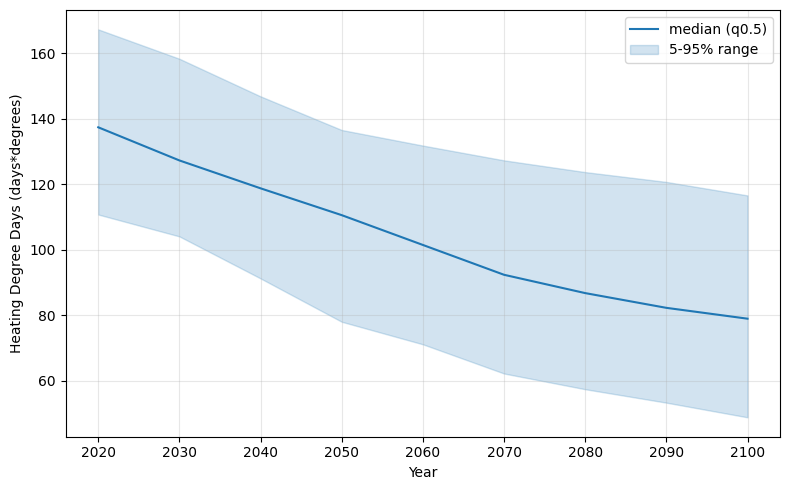

In [20]:
from rimeX.preproc.quantilemaps import make_timesensitive_quantilemap_prediction
quantile_maps = {
    2020: 'data/quantilemaps_regional_admin/heating-degree-days/AFR/heating-degree-days_annual_afr_latweight_eq.nc',
    2030: 'data/quantilemaps_regional_admin/heating-degree-days/AFR/heating-degree-days_annual_afr_latweight_eq.nc',
    2040: 'data/quantilemaps_regional_admin/heating-degree-days/AFR/heating-degree-days_annual_afr_latweight_eq.nc',
    2050: 'data/quantilemaps_regional_admin/heating-degree-days/AFR/heating-degree-days_annual_afr_latweight_eq.nc',
    2060: 'data/quantilemaps_regional_admin/heating-degree-days/AFR/heating-degree-days_annual_afr_latweight_eq.nc',
    2070: 'data/quantilemaps_regional_admin/heating-degree-days/AFR/heating-degree-days_annual_afr_latweight_eq.nc',
    2080: 'data/quantilemaps_regional_admin/heating-degree-days/AFR/heating-degree-days_annual_afr_latweight_eq.nc',
    2090: 'data/quantilemaps_regional_admin/heating-degree-days/AFR/heating-degree-days_annual_afr_latweight_eq.nc',
    2100: 'data/quantilemaps_regional_admin/heating-degree-days/AFR/heating-degree-days_annual_afr_latweight_eq.nc',
}

timesensitive_emulation = make_timesensitive_quantilemap_prediction(quantile_maps,GMT_ensemble,'AFR', 'heating-degree-days', samples=5000, quantiles=[0.5, .05, .95], skipna = True) 
plot_emulation_timeseries(timesensitive_emulation)

## Next steps

This concludes the core RIME-X preprocessing-to-emulation workflow: from raw indicator data, through regional aggregation and quantile maps, to emulated timeseries under a GMT scenario. If you still need to generate your own GMT ensemble from an SCM (rather than using the ready-made NGFS file from this tutorial), see `005_run_FaIR.ipynb`.

## Appendix: additional emulation config options

The example above sets the GMT ensemble and quantile map paths directly, and passes options like `samples`, `quantiles`, and `skipna` explicitly to `make_quantilemap_prediction`. A few defaults for these come from the `[emulator]` section of `config.toml`, and there's a command-line equivalent as well.

**Config keys (`config.toml`)**

| Key | Type | Description |
|---|---|---|
| `emulator.projection_baseline` | [int, int] | Default baseline period (e.g. `[1850, 1900]`) used when expressing GMT relative to a reference period -- the same kind of baseline you'd pass to `load_GMT_ensemble(projection_baseline=...)`. |
| `emulator.projection_baseline_offset` | float | Default offset added after baseline-centering (e.g. `0.85`°C, to shift a pre-industrial-relative baseline to match observed warming) -- passed as `load_GMT_ensemble(projection_baseline_offset=...)`. |
| `emulator.quantiles` | list[float] | Default output quantiles for an emulation, e.g. `[0.01, 0.05, 0.25, 0.5, 0.75, 0.95, 0.99]` -- the same role as the `quantiles` argument in `make_quantilemap_prediction`, just a broader default set than the `[0.5, .05, .95]` we used in this tutorial. |
| `emulator.warming_level_step` | float | Step size used for interpolating between discrete warming levels when running emulations from the command line with `--interp-warming-level` (see below). |
